# 03. Networks

In the previous notebooks, we have focused on single neuron models. However, one of the main strengths of AxonML is its ability to efficiently simulate large networks of neurons with complex morphologies. In this notebook, we will explore how to set up and simulate networks of branched morphologies using AxonML.

## General overview: event-based networks

- AxonML networks are event-driven: a pre-synaptic event (e.g., a voltage or gate crossing a threshold, or a NetStim spike) triggers a message to its post-synaptic targets.
- Each connection is managed by a NetCon, which:
  - Detects pre-synaptic events (intrinsic thresholds, scheduled spikes, or directly implemented in the presynaptic `Mechanism`),
  - Applies weights (and optional schedules) to shape the event amplitude,
  - Delays delivery via per-connection delay buffers.
- Post-synaptic compartments receive these weighted, delayed events as inputs to synapse mechanisms (e.g., exp2syn) which implement `net_receive()`, which update their internal state and contribute currents to the membrane equation.
- Events are sparse in time: only connections with pre-synaptic activity enqueue deliveries, improving efficiency over dense timestep coupling.
- You can drive networks via intrinsic spiking thresholds (e.g., voltage crossings), surrogate/differentiable gates during training, or explicit schedules (NetStim, manual `schedule()` calls).

## Example: Ring Network of Branched Neurons

We will create a simple ring network of branched neurons, where each neuron is connected to its two nearest neighbors. We will use the same branched morphology defined in the previous notebook and set up synaptic connections between the neurons.

In [1]:
import axonml as ax
from axonml.models.mod import hh

model = ax.Tree.from_asc(
    "example.asc", 
    v_init=-65.0, 
    celsius=6.3,
    rhoa=100.0,
    N=5
)  # Load morphology from file, set initial voltage and temperature, create 5 instances

model.insert(hh)  # Insert Hodgkin-Huxley dynamics into all compartments


--No graphics will be displayed.


Now lets insert synapses and connect the neurons in a ring topology.

In [2]:
from axonml.models.mod import exp2syn

model.soma.insert(exp2syn, tau1=0.2, tau2=1.0)  # Insert an exponential synapse at the soma of each neuron

net = ax.Network({"hh": model})  
# Create a network with the branched morphology model. The population is named "hh".

Now we connect in a ring topology.

In [3]:
import torch
net.connect_one_to_one(
    net.hh.soma,
    net.hh.soma[torch.roll(torch.arange(5), shifts=-1)],
    net.hh.mech.exp2syn,
    threshold=0.0,
    weight=0.1,
    delay=5.0,
)

```{important}
We have surreptitiously introduced a powerful feature of AxonML here that we have not explicitly highlighted before: the ability to index into `Slice`s using PyTorch-style indexing. This allows for very flexible and efficient specification of connectivity patterns between neurons in a network. Here, we used `torch.roll` to create a ring topology by connecting each neuron's soma to its neighbor's soma in a circular fashion.
```

```{note}
We use a double exponential synapse model (`exp2syn`) for the synaptic connections, with rising and falling time constants $\tau_1$ and $\tau_2$, respectively, that we have set explicitly (the defaults are 0.1 ms and 10.0 ms). You can explore other synaptic models available in AxonML or define your own custom synaptic models.
```

```{note}
We set the synaptic weight to `0.1` and the delay to `5.0 ms`. You can adjust these parameters to see how they affect the network dynamics.
```

We can now stimulate and run:

In [4]:
from axonml.units import nA, ms

net.hh.delete_injections()
net.hh.soma[0].inject(ax.mono_rect(amp=2.0 * nA, pw=0.5 * ms, delay=1.0 * ms))
rec = ax.callbacks.RecorderLambda(
    {"somas": lambda net: net.hh.soma.v}
)

tstop, dt = 40.0 * ms, 0.025 * ms

rec.reset()
net.initialize(dt=dt)
net.run(tstop=tstop, callbacks=[rec])

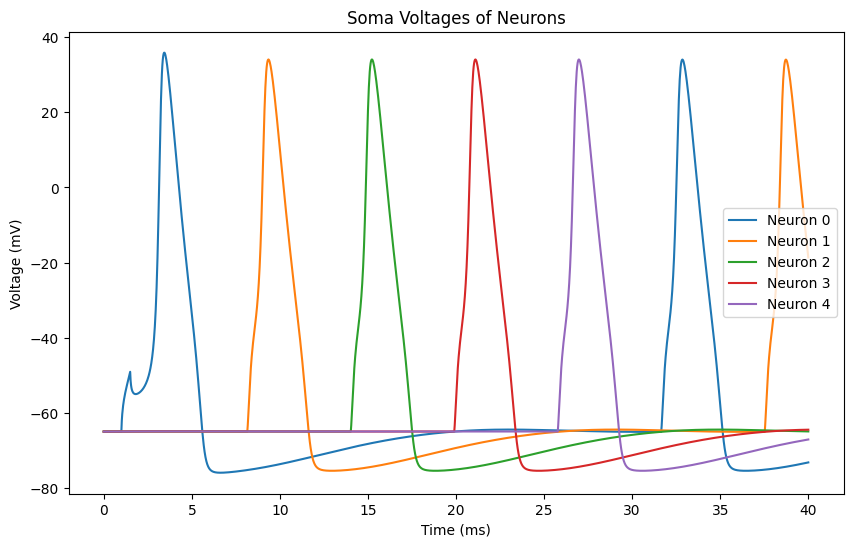

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6), dpi=100)

t = torch.arange(0, tstop+dt, dt)

soma_voltages = rec.numpy('somas')
for i in range(5):
    plt.plot(t, soma_voltages[:, i], label=f'Neuron {i}')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title('Soma Voltages of Neurons')
plt.legend()
plt.show()

Awesome! We have successfully set up and simulated a ring network of branched neurons using AxonML. We can see that with a single initial pulse delivered to the first neuron, the activity propagates through the network in a ring topology, eventually returning to the first neuron and continuing the cycle. We encourage you to further explore different network topologies (perhaps try connecting axonal compartments to dendritic compartments?), synaptic models, and stimulation protocols to study various aspects of neural network dynamics.